#### Assumptions Made-
- The `Order City` is treated as the facility identifier.
- We use `order date (DateOrders)` as the operational date for aggregation.
- For delay calculation we consider negative delays as 0. Delay = (Actual shipping days) − (Planned shipping days)
- We group the data by week. So instead of looking at every single order, we look at one number per city per week.
- A week is labeled exceedence when mean_delay >= 2 days.
- We did not have the real EM-DAT/UNCTAD proxies, so dummy zeros were added as placeholder features.
- We keep the last 20 ISO weeks from the holdout as the test set,  rest weeks are under training set.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor, XGBClassifier

plt.style.use("default")

RANDOM_STATE = 42
X_DELAY_THRESHOLD = 2.0


In [28]:
data_path = "/content/DataCoSupplyChainDataset.csv"

df = pd.read_csv(data_path, encoding="latin1")
print(df.shape)
df.head()


(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [29]:
df["order_date"] = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")

df = df.dropna(subset=["order_date"]).copy()

df["facility"] = df["Order City"].astype(str)

df["delay_days"] = (
    df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]
)

df["delay_days"] = df["delay_days"].clip(lower=0)

df["sla_breach"] = df["Late_delivery_risk"].astype(int)

df[["order_date", "facility", "delay_days", "sla_breach"]].head()


,order_date,facility,delay_days,sla_breach
0,2018-01-31 22:56:00,Bekasi,0,0
1,2018-01-13 12:27:00,Bikaner,1,1
2,2018-01-13 12:06:00,Bikaner,0,0
3,2018-01-13 11:45:00,Townsville,0,0
4,2018-01-13 11:24:00,Townsville,0,0


In [30]:
iso = df["order_date"].dt.isocalendar()
df["iso_year"] = iso.year
df["iso_week"] = iso.week

df["week_start"] = df["order_date"] - pd.to_timedelta(df["order_date"].dt.weekday, unit="D")
df["week_start"] = df["week_start"].dt.normalize()

weekly = (
    df
    .groupby(["facility", "iso_year", "iso_week", "week_start"], as_index=False)
    .agg(
        mean_delay=("delay_days", "mean"),
        sla_breach_rate=("sla_breach", "mean"),
        order_count=("sla_breach", "size"),
    )
)

weekly["exceed"] = (weekly["mean_delay"] >= X_DELAY_THRESHOLD).astype(int)

weekly.head()


,facility,iso_year,iso_week,week_start,mean_delay,sla_breach_rate,order_count,exceed
0,Aachen,2015,25,2015-06-15,1.000000,1.000000,2,0
1,Aachen,2015,27,2015-06-29,0.666667,0.666667,3,0
2,Aachen,2015,28,2015-07-06,1.000000,1.000000,3,0
3,Aachen,2015,30,2015-07-20,1.000000,1.000000,2,0
4,Aachen,2015,32,2015-08-03,1.500000,0.750000,4,0


In [31]:
weekly["weekofyear"] = weekly["iso_week"].astype(int)

weekly["week_sin"] = np.sin(2 * np.pi * weekly["weekofyear"] / 52.0)
weekly["week_cos"] = np.cos(2 * np.pi * weekly["weekofyear"] / 52.0)

weekly["is_year_end"] = weekly["weekofyear"].isin([51, 52, 1]).astype(int)

weekly["emdat_proxy"] = 0.0
weekly["unctad_proxy"] = 0.0

weekly = weekly.sort_values(["facility", "week_start"]).reset_index(drop=True)

for lag in [1, 2]:
    weekly[f"lag{lag}_delay"] = (
        weekly
        .groupby("facility")["mean_delay"]
        .shift(lag)
    )
    weekly[f"lag{lag}_sla_rate"] = (
        weekly
        .groupby("facility")["sla_breach_rate"]
        .shift(lag)
    )

weekly = weekly.dropna(subset=["lag1_delay", "lag1_sla_rate"]).reset_index(drop=True)

weekly.head()


,facility,iso_year,iso_week,week_start,mean_delay,sla_breach_rate,order_count,exceed,weekofyear,week_sin,week_cos,is_year_end,emdat_proxy,unctad_proxy,lag1_delay,lag1_sla_rate,lag2_delay,lag2_sla_rate
0,Aachen,2015,27,2015-06-29,0.666667,0.666667,3,0,27,-0.120537,-0.992709,0,0.0,0.0,1.000000,1.000000,NaN,NaN
1,Aachen,2015,28,2015-07-06,1.000000,1.000000,3,0,28,-0.239316,-0.970942,0,0.0,0.0,0.666667,0.666667,1.000000,1.000000
2,Aachen,2015,30,2015-07-20,1.000000,1.000000,2,0,30,-0.464723,-0.885456,0,0.0,0.0,1.000000,1.000000,0.666667,0.666667
3,Aachen,2015,32,2015-08-03,1.500000,0.750000,4,0,32,-0.663123,-0.748511,0,0.0,0.0,1.000000,1.000000,1.000000,1.000000
4,Aachen,2015,38,2015-09-14,0.000000,0.000000,5,0,38,-0.992709,-0.120537,0,0.0,0.0,1.500000,0.750000,1.000000,1.000000


In [32]:
weekly = weekly.sort_values("week_start").reset_index(drop=True)

unique_weeks = weekly["week_start"].sort_values().unique()
n_holdout_weeks = 20
holdout_weeks = unique_weeks[-n_holdout_weeks:]

train_mask = ~weekly["week_start"].isin(holdout_weeks)
test_mask = weekly["week_start"].isin(holdout_weeks)

train = weekly[train_mask].copy()
test = weekly[test_mask].copy()

print("Train rows:", train.shape[0], "Test rows:", test.shape[0])


Train rows: 15949 Test rows: 3023


In [33]:
fac_week_mean = (
    train
    .groupby(["facility", "weekofyear"])["mean_delay"]
    .mean()
    .to_dict()
)

fac_mean = (
    train
    .groupby("facility")["mean_delay"]
    .mean()
    .to_dict()
)

global_mean = train["mean_delay"].mean()

def seasonal_naive_predict(row):
    key = (row["facility"], row["weekofyear"])
    if key in fac_week_mean:
        return fac_week_mean[key]
    fac = row["facility"]
    if fac in fac_mean:
        return fac_mean[fac]
    return global_mean

test["pred_baseline_delay"] = test.apply(seasonal_naive_predict, axis=1)

test[["facility", "week_start", "mean_delay", "pred_baseline_delay"]].head()


,facility,week_start,mean_delay,pred_baseline_delay
15949,Molina de Segura,2017-09-18,0.000000,2.000000
15950,Amiens,2017-09-18,1.000000,0.764172
15951,Draguignan,2017-09-18,2.000000,1.250000
15952,Eastbourne,2017-09-18,3.142857,1.291667
15953,Fontainebleau,2017-09-18,4.000000,1.300000


In [34]:
all_facilities = weekly["facility"].astype("category")
weekly["facility_code"] = all_facilities.cat.codes

train = weekly[train_mask].copy()
test = weekly[test_mask].copy()

fac_week_mean = (
    train
    .groupby(["facility", "weekofyear"])["mean_delay"]
    .mean()
    .to_dict()
)

fac_mean = (
    train
    .groupby("facility")["mean_delay"]
    .mean()
    .to_dict()
)

global_mean = train["mean_delay"].mean()

def seasonal_naive_predict(row):
    key = (row["facility"], row["weekofyear"])
    if key in fac_week_mean:
        return fac_week_mean[key]
    fac = row["facility"]
    if fac in fac_mean:
        return fac_mean[fac]
    return global_mean

test["pred_baseline_delay"] = test.apply(seasonal_naive_predict, axis=1)

feature_cols = [
    "facility_code",
    "weekofyear",
    "week_sin",
    "week_cos",
    "is_year_end",
    "emdat_proxy",
    "unctad_proxy",
    "lag1_delay",
    "lag1_sla_rate",
    "lag2_delay",
    "lag2_sla_rate",
]

X_train = train[feature_cols].values
X_test = test[feature_cols].values

y_reg_train = train["mean_delay"].values
y_reg_test = test["mean_delay"].values

y_clf_train = train["exceed"].values
y_clf_test = test["exceed"].values

reg = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
reg.fit(X_train, y_reg_train)

test["pred_xgb_delay"] = reg.predict(X_test)

clf = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
clf.fit(X_train, y_clf_train)

test["pred_xgb_prob"] = clf.predict_proba(X_test)[:, 1]
test["pred_xgb_label"] = (test["pred_xgb_prob"] >= 0.5).astype(int)

test.head()


,facility,iso_year,iso_week,week_start,mean_delay,sla_breach_rate,order_count,exceed,weekofyear,week_sin,...,unctad_proxy,lag1_delay,lag1_sla_rate,lag2_delay,lag2_sla_rate,facility_code,pred_baseline_delay,pred_xgb_delay,pred_xgb_prob,pred_xgb_label
15949,Molina de Segura,2017,38,2017-09-18,0.000000,0.0,1,0,38,-0.992709,...,0.0,1.0,1.0,0.000000,0.000000,1832,2.000000,1.003655,0.109168,0
15950,Amiens,2017,38,2017-09-18,1.000000,1.0,5,0,38,-0.992709,...,0.0,0.0,0.0,0.444444,0.111111,84,0.764172,1.059218,0.121086,0
15951,Draguignan,2017,38,2017-09-18,2.000000,1.0,5,1,38,-0.992709,...,0.0,0.0,0.0,1.000000,1.000000,809,1.250000,1.003217,0.148409,0
15952,Eastbourne,2017,38,2017-09-18,3.142857,1.0,7,1,38,-0.992709,...,0.0,0.0,0.0,1.500000,1.000000,838,1.291667,0.988717,0.138968,0
15953,Fontainebleau,2017,38,2017-09-18,4.000000,1.0,3,1,38,-0.992709,...,0.0,1.0,1.0,1.600000,1.000000,934,1.300000,0.958780,0.153949,0


In [35]:
def smape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom)

smape_baseline = smape(test["mean_delay"], test["pred_baseline_delay"])
smape_xgb = smape(test["mean_delay"], test["pred_xgb_delay"])

pr_auc_xgb = average_precision_score(y_clf_test, test["pred_xgb_prob"])
f1_xgb = f1_score(y_clf_test, test["pred_xgb_label"])

print("sMAPE (baseline):", smape_baseline)
print("sMAPE (XGB):     ", smape_xgb)
print("PR-AUC (XGB):    ", pr_auc_xgb)
print("F1 (XGB):        ", f1_xgb)


sMAPE (baseline): 0.8871373821741698
sMAPE (XGB):      0.7789156498378338
PR-AUC (XGB):     0.16517293358497537
F1 (XGB):         0.0


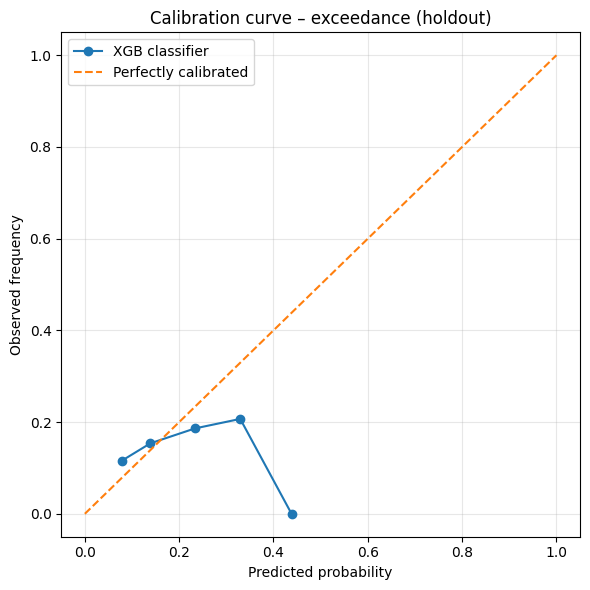

In [36]:
prob_true, prob_pred = calibration_curve(
    y_clf_test, test["pred_xgb_prob"], n_bins=10, strategy="uniform"
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="XGB classifier")
plt.plot([0, 1], [0, 1], "--", label="Perfectly calibrated")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration curve – exceedance (holdout)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Plotting for facility: Yakarta


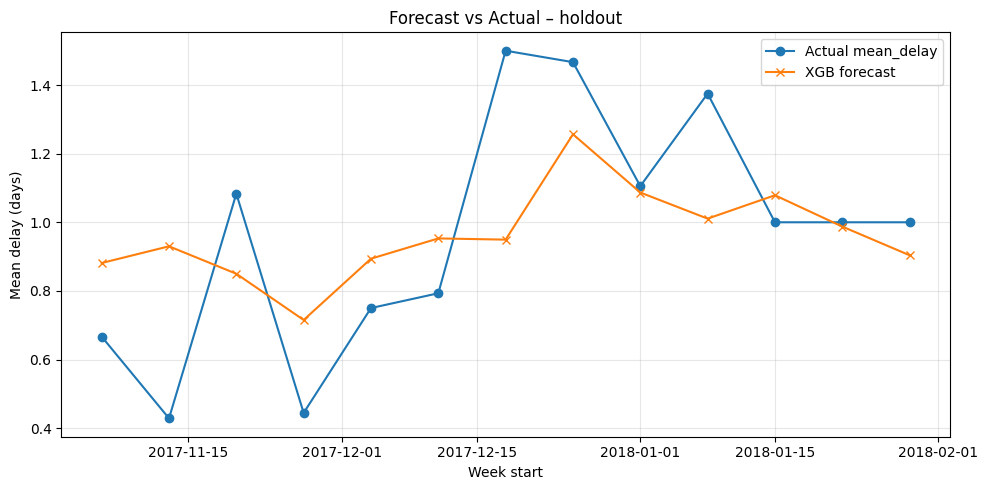

In [37]:
fac_counts = test["facility"].value_counts()
top_facility = fac_counts.index[0]
print("Plotting for facility:", top_facility)

plot_df = (
    test[test["facility"] == top_facility]
    .sort_values("week_start")
    .copy()
)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["week_start"], plot_df["mean_delay"], marker="o", label="Actual mean_delay")
plt.plot(plot_df["week_start"], plot_df["pred_xgb_delay"], marker="x", label="XGB forecast")

plt.xlabel("Week start")
plt.ylabel("Mean delay (days)")
plt.title(f"Forecast vs Actual – holdout")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("forecast_vs_actual.png", dpi=150)
plt.show()


In [38]:
metrics_rows = [
    {
        "model": "seasonal_naive",
        "target_type": "regression",
        "target": "mean_delay",
        "split": "holdout",
        "metric": "sMAPE",
        "value": smape_baseline,
    },
    {
        "model": "xgboost",
        "target_type": "regression",
        "target": "mean_delay",
        "split": "holdout",
        "metric": "sMAPE",
        "value": smape_xgb,
    },
    {
        "model": "xgboost",
        "target_type": "classification",
        "target": f"exceed_delay_{X_DELAY_THRESHOLD}",
        "split": "holdout",
        "metric": "PR_AUC",
        "value": pr_auc_xgb,
    },
    {
        "model": "xgboost",
        "target_type": "classification",
        "target": f"exceed_delay_{X_DELAY_THRESHOLD}",
        "split": "holdout",
        "metric": "F1",
        "value": f1_xgb,
    },
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv("predict_metrics.csv", index=False)
metrics_df



,model,target_type,target,split,metric,value
0,seasonal_naive,regression,mean_delay,holdout,sMAPE,0.887137
1,xgboost,regression,mean_delay,holdout,sMAPE,0.778916
2,xgboost,classification,exceed_delay_2.0,holdout,PR_AUC,0.165173
3,xgboost,classification,exceed_delay_2.0,holdout,F1,0.000000


The F1 score is 0 because the exceedance target is highly imbalanced (2585 zeros vs 438 ones).
With this imbalance, the XGBoost classifier learns that predicting only the majority class (0) minimizes loss at the default 0.5 threshold.
Since no positive predictions are made, precision and recall are both 0, giving an F1 of 0.
